# Sharing an error model between two experiments

Two experiments measure the same line, and each one carries its own
normalisation defect.  We know how to give a single dataset an error model; the
question now is what to do when we have two, and we believe something about
them *jointly*.

There are two quite different things we might mean by "they share an error
model", and `rxmc` spells them differently:

- **Case B — share the parameter.**  Each dataset has its own normalisation
  measurement, but we believe the two magnitudes are the same number.  We pass
  the same `Parameter` object to a term on each comparison: one column in the
  chain, two block-diagonal blocks in the covariance, and the datasets stay
  statistically independent.
- **Case A — share the mode.**  Both were normalised against the same uncertain
  flux, so a single unknown moves them together.  One term spans both
  comparisons, and the covariance grows off-diagonal blocks that couple the
  datasets.

They are different statistical models, not two spellings of one.  Recipe 5 has
both; here we watch what each does to the same pair of datasets, including what
it costs us to declare the wrong one.

Recipes: 5

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## Two experiments, one line

The first experiment reports 5 % noise and came out 10 % low; the second reports
2.5 % noise and came out 10 % high.  Neither reports a normalisation
uncertainty, so between them they disagree by 20 % while claiming a precision of
a few per cent.

In [2]:
rng = np.random.default_rng(16)
truth = {"m": 0.6, "b": 2.0}

x1 = np.linspace(0.01, 1.0, 15)
y1_true = truth["m"] * x1 + truth["b"]
y1 = (y1_true + rng.normal(0.0, 0.05 * y1_true)) * 0.9  # 10 % low
data1 = rx.Dataset(x1, y1, 0.05 * y1, label="experiment A")

x2 = np.linspace(0.01, 0.8, 27)
y2_true = truth["m"] * x2 + truth["b"]
y2 = (y2_true + rng.normal(0.0, 0.025 * y2_true)) * 1.1  # 10 % high
data2 = rx.Dataset(x2, y2, 0.025 * y2, label="experiment B")

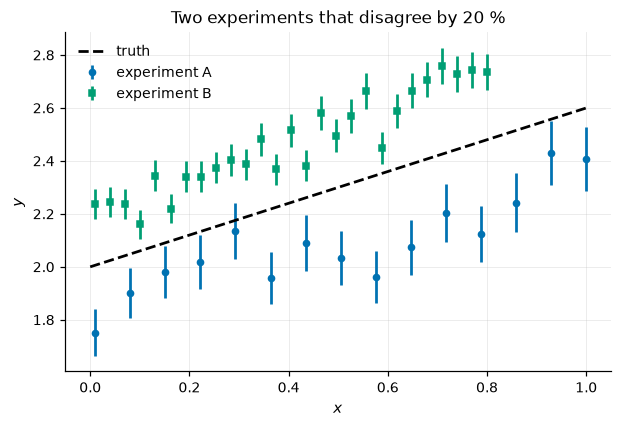

In [3]:
x_fine = np.linspace(0.0, 1.0, 40)
fig, ax = plt.subplots()
ax.errorbar(
    data1.x,
    data1.y,
    data1.y_err,
    fmt="o",
    color=plotstyle.COLOURS[0],
    label=data1.label,
)
ax.errorbar(
    data2.x,
    data2.y,
    data2.y_err,
    fmt="s",
    color=plotstyle.COLOURS[2],
    label=data2.label,
)
ax.plot(x_fine, truth["m"] * x_fine + truth["b"], "--", color="k", label="truth")
ax.set(xlabel="$x$", ylabel="$y$", title="Two experiments that disagree by 20 %")
ax.legend()
plt.show()

## The model and the way we run a fit

The same line, the same wide prior, and the same three helpers as in
`error_models`: `fit`, `band` and `summary`.

In [4]:
m = rx.Parameter("m", prior=stats.norm(2.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(5.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp1, comp2 = rx.Comparison(data1, line), rx.Comparison(data2, line)

In [5]:
def fit(problem, seed, n_walkers=24, n_steps=1800):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def band(problem, samples, levels=(5, 95)):
    on_fine = line.bind(x_fine)
    cols = problem.columns(line.params)
    return rx.predictive.predictive_band(
        [on_fine(*s[cols]) for s in samples[::10]], levels=levels
    )


def summary(problem, samples):
    return "  ".join(
        f"{n} = {samples[:, i].mean():.3f} +/- {samples[:, i].std():.3f}"
        for i, n in enumerate(problem.names)
    )

## What "shared" means to the compiler

Sharing is by *object identity*, never by name.  Passing one `Parameter` to two
terms gives one column; building two parameters that happen to have the same
name is an error, because the chain would carry two columns with one label.

In [6]:
shared = rx.Parameter("log_eps", prior=stats.norm(np.log(0.05), 1.0))
c_shared = rx.Constraint(
    [comp1, comp2],
    terms=[T.noise_fraction(shared, on=comp1), T.noise_fraction(shared, on=comp2)],
    statistical=False,
)
p_shared = rx.Problem([c_shared])
print("one shared object -> one column: ", p_shared.names)

eps1 = rx.Parameter("log_eps_1", prior=stats.norm(np.log(0.05), 1.0))
eps2 = rx.Parameter("log_eps_2", prior=stats.norm(np.log(0.05), 1.0))
c_separate = rx.Constraint(
    [comp1, comp2],
    terms=[T.noise_fraction(eps1, on=comp1), T.noise_fraction(eps2, on=comp2)],
    statistical=False,
)
print("two objects   -> two columns:   ", rx.Problem([c_separate]).names)

one shared object -> one column:  ['m', 'b', 'log_eps']
two objects   -> two columns:    ['m', 'b', 'log_eps_1', 'log_eps_2']


## Case B: one inferred noise for both

We let a single noise fraction, shared between the datasets, absorb the
disagreement.  It is the only freedom this error model has, so we should expect
it to grow until it covers a 20 % gap that is not noise at all.

In [7]:
s_shared = fit(p_shared, seed=6)
print(summary(p_shared, s_shared))
print(f"inferred noise fraction: {np.exp(s_shared[:, 2]).mean():.3f}")

m = 0.502 +/- 0.133  b = 2.115 +/- 0.065  log_eps = -2.338 +/- 0.114
inferred noise fraction: 0.097


## A normalisation mode per dataset, and then one across both

Two more error models, both of which know what actually happened:

- **a mode per dataset** (still case B in spirit): each experiment gets its own
  rank-one normalisation mode, so each may slide independently;
- **case A**: one mode with `on=[comp1, comp2]`, a single unknown flux that
  moves both together, which fills the off-diagonal blocks.

Our two experiments drifted in *opposite* directions, so we should expect the
per-dataset modes to fit comfortably and case A to struggle: one common factor
cannot pull A up and B down at the same time.

In [8]:
p_stat = rx.Problem([rx.Constraint([comp1, comp2])])
p_per_set = rx.Problem(
    [
        rx.Constraint(
            [comp1, comp2],
            terms=[
                T.normalization(magnitude=0.1, on=comp1),
                T.normalization(magnitude=0.1, on=comp2),
            ],
        )
    ]
)
p_case_a = rx.Problem(
    [
        rx.Constraint(
            [comp1, comp2], terms=[T.normalization(magnitude=0.1, on=[comp1, comp2])]
        )
    ]
)
s_stat = fit(p_stat, seed=7)
s_per_set = fit(p_per_set, seed=8)
s_case_a = fit(p_case_a, seed=9)
for label, p, s in [
    ("statistics only", p_stat, s_stat),
    ("a mode per dataset", p_per_set, s_per_set),
    ("one mode across both (case A)", p_case_a, s_case_a),
]:
    print(f"{label:32s}: {summary(p, s)}")

statistics only                 : m = 0.569 +/- 0.043  b = 2.162 +/- 0.020
a mode per dataset              : m = 0.648 +/- 0.064  b = 2.054 +/- 0.154
one mode across both (case A)   : m = 0.484 +/- 0.573  b = 1.831 +/- 2.202


That is what declaring the wrong sharing costs.

Statistics only is precise and wrong, as usual: $b = 2.162 \pm 0.020$, eight
standard deviations from the truth, because with no way to say "these two
experiments are on different scales" the fit splits the difference and believes
it.

A mode per dataset is the model that matches how the defect arose, and it
behaves: $m = 0.648 \pm 0.064$, $b = 2.054 \pm 0.154$, both covering.

Case A insists that one unknown moved both experiments together.  It cannot
explain a *relative* disagreement, so it does the only thing left: it inflates
the shared scale until the line is barely determined at all
($m = 0.484 \pm 0.573$, $b = 1.831 \pm 2.202$).  The fit does not fail loudly;
it just stops saying anything useful.  Declaring the wrong sharing is not a
small error.

### The covariance, seen directly

`constraint.matrix(theta)` hands us the assembled covariance, which is the
quickest way to see the difference: a mode per dataset leaves the
cross-experiment blocks empty, while one mode across both fills them in.

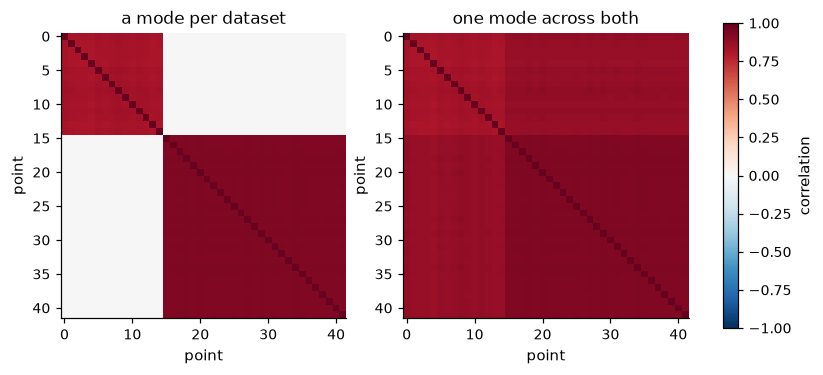

In [9]:
theta = np.array([truth["m"], truth["b"]])
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.6))
for ax, (label, p) in zip(
    axes, [("a mode per dataset", p_per_set), ("one mode across both", p_case_a)]
):
    sigma = p.constraints[0].matrix(theta)
    scale = np.sqrt(np.outer(np.diag(sigma), np.diag(sigma)))
    im = ax.imshow(sigma / scale, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set(title=label, xlabel="point", ylabel="point")
    ax.grid(False)
fig.colorbar(im, ax=axes, label="correlation", fraction=0.03)
plt.show()

In [10]:
runs = {
    "statistics only": (p_stat, s_stat, plotstyle.COLOURS[0], plotstyle.HATCHES[0]),
    "shared inferred noise": (
        p_shared,
        s_shared,
        plotstyle.COLOURS[2],
        plotstyle.HATCHES[1],
    ),
    "a mode per dataset": (
        p_per_set,
        s_per_set,
        plotstyle.COLOURS[4],
        plotstyle.HATCHES[2],
    ),
    "one mode across both": (
        p_case_a,
        s_case_a,
        plotstyle.COLOURS[1],
        plotstyle.HATCHES[3],
    ),
}
bands = {label: band(p, s) for label, (p, s, _, _) in runs.items()}

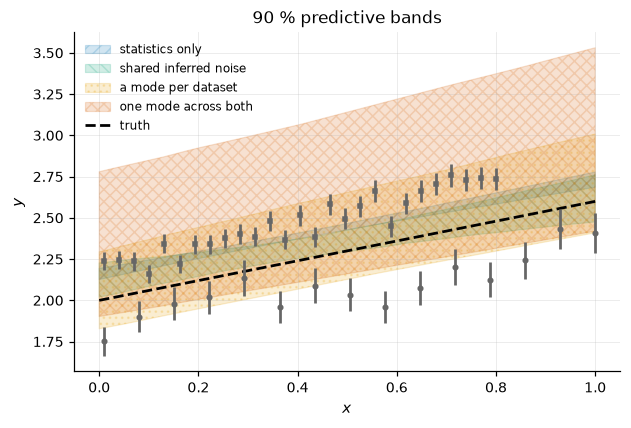

In [11]:
fig, ax = plt.subplots()
for label, (lo, hi) in bands.items():
    _, _, colour, hatch = runs[label]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=label)
ax.plot(x_fine, truth["m"] * x_fine + truth["b"], "--", color="k", label="truth")
ax.errorbar(data1.x, data1.y, data1.y_err, fmt="o", color="0.4", ms=3)
ax.errorbar(data2.x, data2.y, data2.y_err, fmt="s", color="0.4", ms=3)
ax.set(xlabel="$x$", ylabel="$y$", title="90 % predictive bands")
ax.legend(fontsize=8)
plt.show()

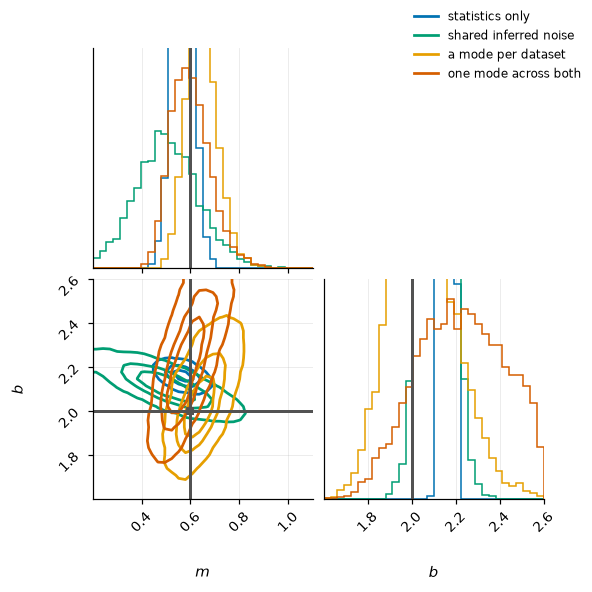

In [12]:
fig = None
for label, (p, s, colour, _) in runs.items():
    fig = corner.corner(
        s[:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[truth["m"], truth["b"]],
        range=[(0.2, 1.1), (1.6, 2.6)],
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=lab) for lab, (_, _, c, _) in runs.items()
    ],
    loc="upper right",
    fontsize=8,
)
plt.show()

## Takeaways

- Sharing a `Parameter` object couples the *parameters*; a term spanning
  comparisons couples the *data*.  Both are declarations, never configuration,
  and the compiler tells us which we wrote: one column, or off-diagonal blocks.
- A shared diagonal noise can only inflate.  Faced with two experiments that
  disagree by 20 %, it grows until it covers the gap, which fits neither the
  data nor the story.
- A normalisation mode per dataset lets each experiment slide on its own, and
  is the model that matches how the defect arose here.
- One mode across both says a single unknown moved them together.  That is a
  stronger statement, and here it is the wrong one: our experiments drifted
  apart, not together, so the fit could only widen until it said nothing.  It
  is the right model when the experiments really do share a calibration —
  recipe 37 is the version for several quantities of one experiment whose
  normalisations are correlated.